# Module 4 - Session 4: Practical Exercises

Objective: Implement K-Means with scikit-learn, visualize the learned clusters, and compare the Elbow and Silhouette methods for choosing the number of clusters.

## Exercise 1 - Trace K-Means (Conceptual)
We cluster A(1,1), B(1,2), C(2,1), D(5,4), E(5,5), F(6,4) with k=2, starting from C1=(1,1) and C2=(5,4).

**Iteration 1 (assignment)**

| Point | dist to C1 | dist to C2 | Cluster |
|-------|------------|------------|---------|
| A(1,1) | 0.00 | 5.00 | C1 |
| B(1,2) | 1.00 | 4.47 | C1 |
| C(2,1) | 1.00 | 4.24 | C1 |
| D(5,4) | 5.00 | 0.00 | C2 |
| E(5,5) | 5.66 | 1.00 | C2 |
| F(6,4) | 5.83 | 1.00 | C2 |

**Iteration 1 (update)**
- C1 = mean of A,B,C = (4/3, 4/3) ? (1.33, 1.33)
- C2 = mean of D,E,F = (16/3, 13/3) ? (5.33, 4.33)

**Iteration 2**
- Re-assigning with the new centroids keeps A,B,C with C1 and D,E,F with C2 (nearest distances stay the same groups).
- Recomputing the means yields the same centroids, so the clustering stabilizes after the first update.

In [1]:
# Quick distance check for Exercise 1
import numpy as np
import pandas as pd

points = {
    'A': (1, 1),
    'B': (1, 2),
    'C': (2, 1),
    'D': (5, 4),
    'E': (5, 5),
    'F': (6, 4),
}

C1 = np.array([1, 1], dtype=float)
C2 = np.array([5, 4], dtype=float)

rows = []
for name, pt in points.items():
    p = np.array(pt, dtype=float)
    rows.append({
        'point': name,
        'dist_C1': np.linalg.norm(p - C1),
        'dist_C2': np.linalg.norm(p - C2),
        'cluster': 'C1' if np.linalg.norm(p - C1) <= np.linalg.norm(p - C2) else 'C2'
    })

assign_df = pd.DataFrame(rows).set_index('point')
new_C1 = assign_df[assign_df['cluster'] == 'C1'][['dist_C1', 'dist_C2']].index.map(points.__getitem__)
new_C2 = assign_df[assign_df['cluster'] == 'C2'][['dist_C1', 'dist_C2']].index.map(points.__getitem__)

C1_updated = np.mean(np.vstack(new_C1), axis=0)
C2_updated = np.mean(np.vstack(new_C2), axis=0)

assign_df, C1_updated, C2_updated


(        dist_C1   dist_C2 cluster
 point                            
 A      0.000000  5.000000      C1
 B      1.000000  4.472136      C1
 C      1.000000  4.242641      C1
 D      5.000000  0.000000      C2
 E      5.656854  1.000000      C2
 F      5.830952  1.000000      C2,
 array([1.33333333, 1.33333333]),
 array([5.33333333, 4.33333333]))

## Exercise 2 - Implement K-Means (Coding)
We cluster a synthetic 2D dataset with 4 blobs, color points by their predicted cluster, and overlay the learned centroids.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8')


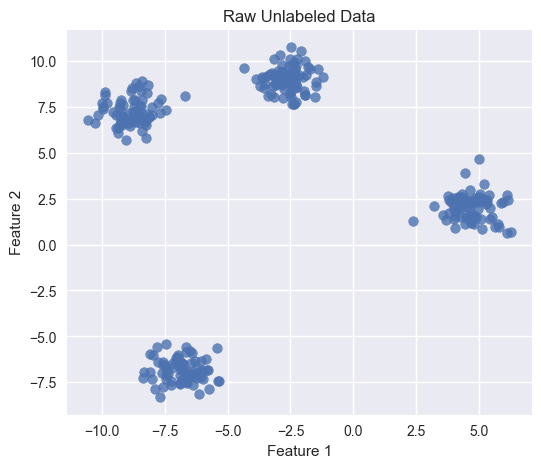

In [3]:
# Generate synthetic data with 4 distinct clusters
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.8)
plt.title('Raw Unlabeled Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


In [4]:
# Train K-Means with k=4
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_


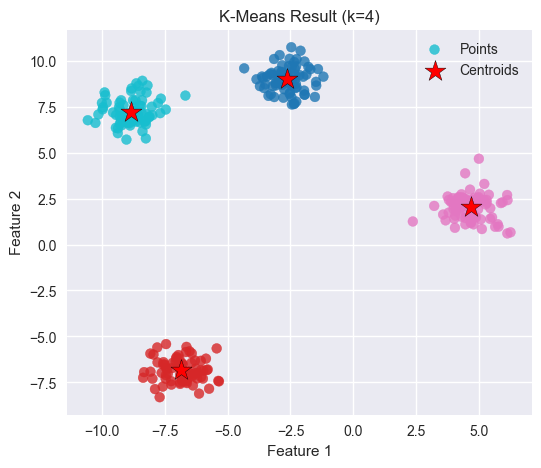

In [5]:
# Visualize clustered data and centroids
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='tab10', alpha=0.8, label='Points')
plt.scatter(centers[:, 0], centers[:, 1], marker='*', s=250, c='red', edgecolor='black', label='Centroids')
plt.title('K-Means Result (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


## Exercise 3 - Elbow Method
Compute WCSS (inertia) for k from 1 to 10 and visualize the elbow.

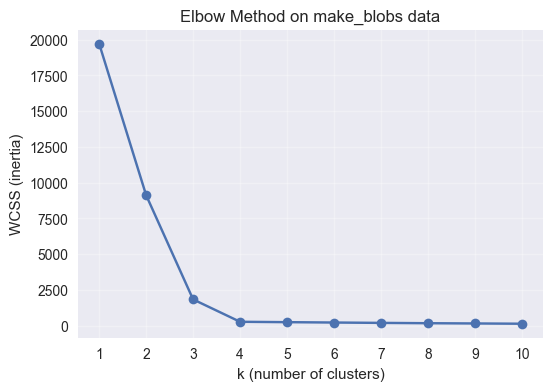

In [6]:
ks = range(1, 11)
wcss = []
for k in ks:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(ks), wcss, 'o-')
plt.xticks(ks)
plt.xlabel('k (number of clusters)')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method on make_blobs data')
plt.grid(True, alpha=0.3)
plt.show()


## Exercise 4 - Silhouette Method (Challenge)
Overlay Elbow (WCSS) and Silhouette scores to pick k, then repeat with a noisier dataset where the Elbow is ambiguous.

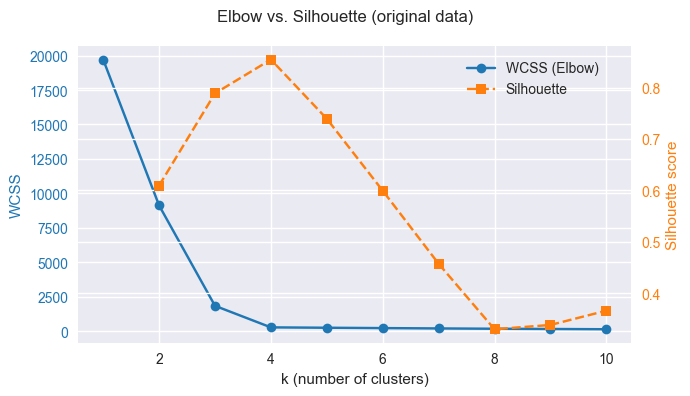

In [7]:
# Combined Elbow + Silhouette on the original dataset
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k) if k > 1 else np.nan
    sil_scores.append(score)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(list(ks), wcss, 'o-', color='tab:blue', label='WCSS (Elbow)')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(list(ks)[1:], sil_scores[1:], 's--', color='tab:orange', label='Silhouette')
ax2.set_ylabel('Silhouette score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.suptitle('Elbow vs. Silhouette (original data)')
fig.tight_layout()
plt.show()


### Exercise 4.2 - When the Elbow is ambiguous
Using `cluster_std=2.8` creates overlapping blobs: the WCSS curve becomes smoother (no sharp elbow), but the Silhouette curve still peaks clearly at k?3. This shows how the Silhouette method can disambiguate the choice.

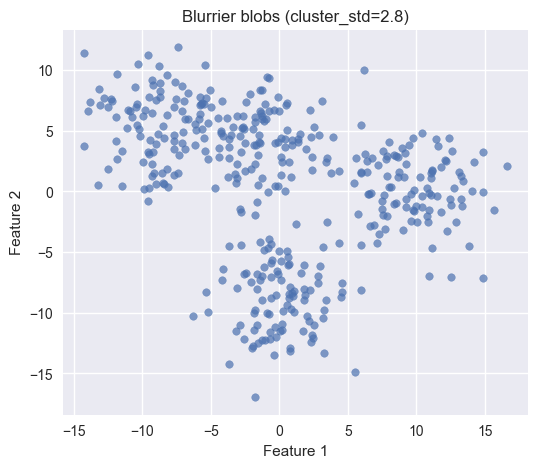

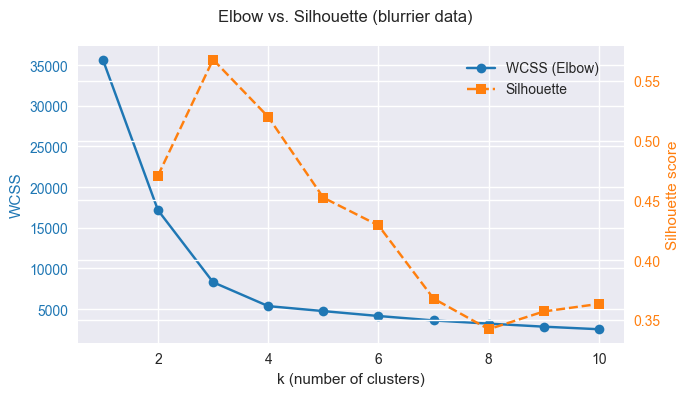

In [8]:
# New blurrier dataset
X_blur, _ = make_blobs(n_samples=400, centers=4, cluster_std=2.8, random_state=7)

plt.figure(figsize=(6, 5))
plt.scatter(X_blur[:, 0], X_blur[:, 1], s=30, alpha=0.7)
plt.title('Blurrier blobs (cluster_std=2.8)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

ks_blur = range(1, 11)
wcss_blur = []
sil_blur = []
for k in ks_blur:
    km = KMeans(n_clusters=k, n_init=10, random_state=7)
    labels_blur = km.fit_predict(X_blur)
    wcss_blur.append(km.inertia_)
    sil_blur.append(silhouette_score(X_blur, labels_blur) if k > 1 else np.nan)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(list(ks_blur), wcss_blur, 'o-', color='tab:blue', label='WCSS (Elbow)')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(list(ks_blur)[1:], sil_blur[1:], 's--', color='tab:orange', label='Silhouette')
ax2.set_ylabel('Silhouette score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.suptitle('Elbow vs. Silhouette (blurrier data)')
fig.tight_layout()
plt.show()
